# Different-control hypothesis (M1): training RNNs to fit EMG low-dimensional trajectories

- Train rate-based recurrent neural networks (RNNs) to reproduce the low-dimensional muscle activity (EMG PCs) during the arm-pedalling task, under the **different-control hypothesis**. In this hypothesis, discrete and rhythmic movements are generated by different control strategies.


Documented by Ayelen Oyarzo

December 2025

In [1]:
# Loading the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.src.layers import RNN
import tensorflow.keras.backend as K


from pathlib import Path

from scipy.io import savemat
from scipy.io import loadmat
import time

from RNN_functions.rnn_cells_different import MinimalRNNCell
from RNN_functions.rnn_simulation_diff import simulateRNN

## Networks parameters

In [2]:
Nunits = 50         # Number of recurrent units
tau = 4             # Effective time constant
#Nepochs=50000      # Original number of epochs
Nepochs = 10000         # Reduced number of epochs for quicker testing
Nnetworks = 1        # Number of repetitions of the training with different initialisations

## Define directories

In [3]:
BASE_DIR = Path("./Output_files")
INPUT_DIR = BASE_DIR / "RNNs_Inputs"
OUTPUT_DIR = BASE_DIR / "TrainedRNNs" / "M1_different"

## Local functions

In [4]:
def load_animal_mat(animal: str):
    """
    Load MATLAB data file for a given animal.
    """
    fname = INPUT_DIR / f"M1_{animal}_different.mat"
    return loadmat(str(fname))

## Load inputs from Matlab files
Inputs for this type of network are defined by the MATLAB function `Create_inputs_RNN.mat`

In [5]:
ANIMALS = ["Cousteau", "Drake"] # List of animal identifiers
for Animal in ANIMALS:
    # Loading data
    DataDrake = load_animal_mat(Animal)
    InputDrake=DataDrake['Input']
    OutputDrake=DataDrake['Output']
    idx_pos=DataDrake['idx_pos_trial']
    idx_cycle=DataDrake['idx_cycle_trial']
    idx_dir=DataDrake['idx_dir_trial']
    Btask=DataDrake['Btask']
    Btask=K.constant(Btask)
    total_trials=InputDrake.shape[0]

    # Defining training set
    training=np.array([0,1,2,3,16,17,18,19])
    inputs_training=InputDrake[training,:,:]
    outputs_training=OutputDrake[training,:,:]
    idx_pos_train=idx_pos[training]
    idx_cycle_train=idx_cycle[training]
    idx_dir_train=idx_dir[training]

    # Defining test set
    test=np.arange(4,16)
    inputs_test=InputDrake[test,:,:]
    outputs_test=OutputDrake[test,:,:]
    idx_pos_test=idx_pos[test]
    idx_cycle_test=idx_cycle[test]
    idx_dir_test=idx_dir[test]
    Noutputs=outputs_training.shape[2]
    Ninputs=inputs_training.shape[2]
    Ntimes=outputs_training.shape[1]
    Nbatches=outputs_training.shape[0]



 # Plot inputs and outputs used for training

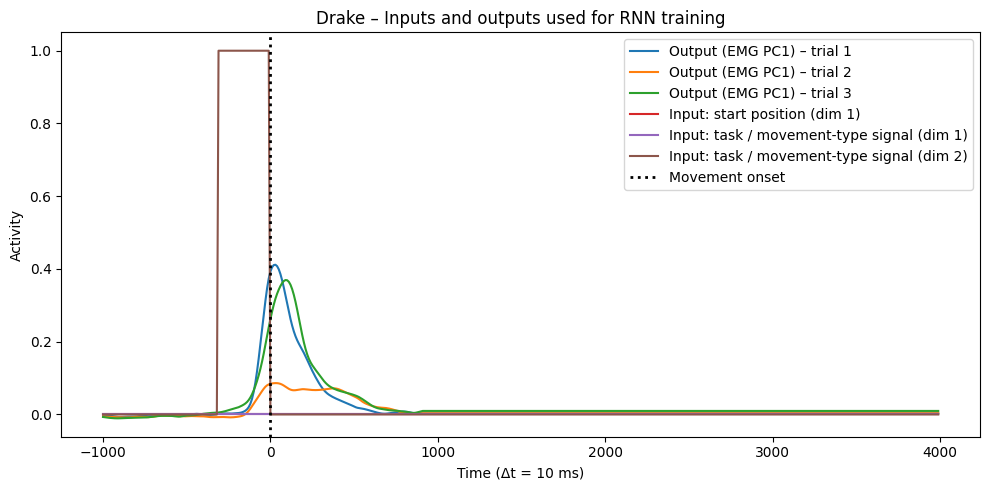

In [6]:

    # PLot from -1000 ms to end

    # Sampling and alignment
    dt_ms = 10
    move_onset_idx = 100             # movement starts at 100 ( 100*10 ms = 1000 ms from trial start)

    # Time axis aligned to movement onset (t=0 at movement start)
    t_ms = (np.arange(Ntimes) - move_onset_idx) * dt_ms

    plt.figure(figsize=(10, 5))

    # Outputs (targets) – first M1 PC for 3 example trials
    plt.plot(t_ms, outputs_training[0,:,0], label="Output (EMG PC1) – trial 1")
    plt.plot(t_ms, outputs_training[1,:,0], label="Output (EMG PC1) – trial 2")
    plt.plot(t_ms, outputs_training[2,:,0], label="Output (EMG PC1) – trial 3")

    # Inputs – example trial
    plt.plot(t_ms, inputs_training[0,:,0],label="Input: start position (dim 1)")
    plt.plot(t_ms, inputs_training[0,:,5],label="Input: task / movement-type signal (dim 1)")
    plt.plot(t_ms, inputs_training[0,:,6],label="Input: task / movement-type signal (dim 2)")

    # Mark movement onset
    plt.axvline(0, color="k", linestyle=":", linewidth=2, label="Movement onset")

    plt.title(f"{Animal} – Inputs and outputs used for RNN training")
    plt.xlabel("Time (Δt = 10 ms)")
    plt.ylabel("Activity")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

# Plot temporal input for each animal

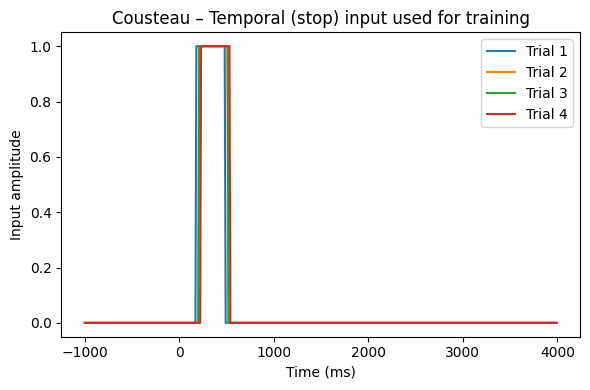

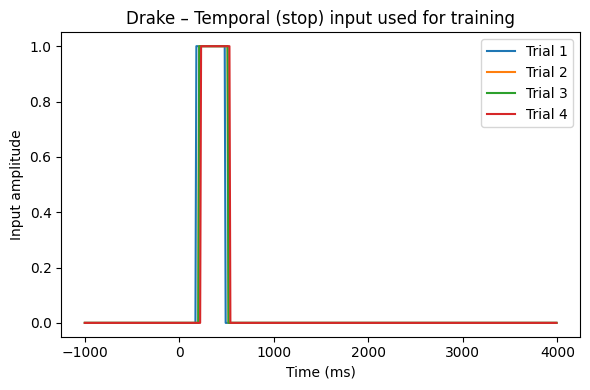

In [7]:

for Animal in ANIMALS:
    plt.figure(figsize=(6, 4))

    plt.plot(t_ms,inputs_training[0, :, 2], label="Trial 1")
    plt.plot(t_ms, inputs_training[1, :, 2], label="Trial 2")
    plt.plot(t_ms, inputs_training[2, :, 2], label="Trial 3")
    plt.plot(t_ms, inputs_training[3, :, 2], label="Trial 4")

    plt.title(f"{Animal} – Temporal (stop) input used for training")
    plt.xlabel("Time (ms)")
    plt.ylabel("Input amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Training the RNN on the task (different-control hypothesis)
- This section trains multiple RNN instances (repetitions) to fit the target low-dimensional trajectories under the different-control hypothesis. Each repetition starts from a different random initialisation of the network weights, while keeping a fixed initial hidden state (S0) to ensure reproducibility across training runs.

In [8]:
for Animal in ANIMALS:

    # Set initial conditions
    #initializer = tf.keras.initializers.Zeros()
    initializer = tf.keras.initializers.RandomNormal(mean=0., stddev=0.1, seed=1)
    S0 = initializer((1, Nunits)).numpy()

    checkpoint_filepath = f"./checkpoint_EMG_Hyp_different_{Animal}.weights.h5"

    for irep in np.arange(0,Nnetworks):
        cell = MinimalRNNCell(Nunits,tau,Btask)

        rnn = keras.layers.RNN(
            cell,
            return_sequences=True)

        model= keras.models.Sequential()
        model.add(keras.Input(shape=(Ntimes,Ninputs))) #seq_length, input_size
        model.add(rnn)
        model.add(keras.layers.Dense(Noutputs))
        model.compile(loss = 'mean_squared_error',optimizer='Adam')
        model.summary()

        # Train the RNN
        tic = time.time()

        model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_filepath,
            save_weights_only=True,
            monitor='loss',
            mode='min',
            save_freq=10,
            save_best_only=True)

        history=model.fit(inputs_training,outputs_training,batch_size=Nbatches,epochs=Nepochs,verbose=0,callbacks=[model_checkpoint_callback])
        toc = time.time()
        print(f"{Animal} rep {irep+1}/{Nnetworks} time(s):", toc - tic)

        model.load_weights(checkpoint_filepath)
        Meval=model.evaluate(inputs_training,outputs_training,batch_size = 1, verbose = 0)
        newA=model.get_weights()
        print(f"{Animal} rep {irep+1}/{Nnetworks} MSE:", Meval)

        newA=model.get_weights()
        #Extract trained parameters from the model
        B=newA[0];
        Bdir=newA[1];
        Bipos=newA[2];
        W=newA[3];
        O=newA[4];
        Ob=newA[5];

        # Save trained parameters and training history to a MATLAB file
        mdic = {"inputs": inputs_training, "B": B, "W":W,"O":O,"Ob":Ob,"Output":outputs_training,
            "Test_input":inputs_test,"Test_Outputs":outputs_test,
            "idx_cycles_train":idx_cycle_train,"idx_pos_train":idx_pos_train,
                "idx_cycles_test":idx_cycle_test,"idx_pos_test":idx_pos_test,
                "idx_dir_train":idx_dir_train,"idx_dir_test":idx_dir_test,
                'Bipos':Bipos,'Initial_state':S0,'Bdir':Bdir,'Btask':Btask,'history':history.history['loss']}

        #savemat(".\Trained_Hyp_Separate\Trained_EMG_Hyp_separate"+Animal+"_"+str(irep+1)+"_Orth_start.mat", mdic)
        out_file = OUTPUT_DIR / f"EMG_{Animal}_Hyp_different_trained_{irep+1}.mat"
        savemat(str(out_file), mdic)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn (RNN)                       │ (None, 500, 50)        │         2,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500, 4)         │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,954 (11.54 KB)

 Trainable params: 2,954 (11.54 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_1 (RNN)                     │ (None, 500, 50)        │         2,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500, 4)         │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,954 (11.54 KB)

 Trainable params: 2,954 (11.54 KB)

 Non-trainable params: 0 (0.00 B)

Drake rep 1/1 time(s): 1371.2467505931854
Drake rep 1/1 MSE: 0.0007009765249677002


# Compare outputs of the trained RNNs with EMG

[Cousteau] Final training loss (Meval): 0.000701
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step


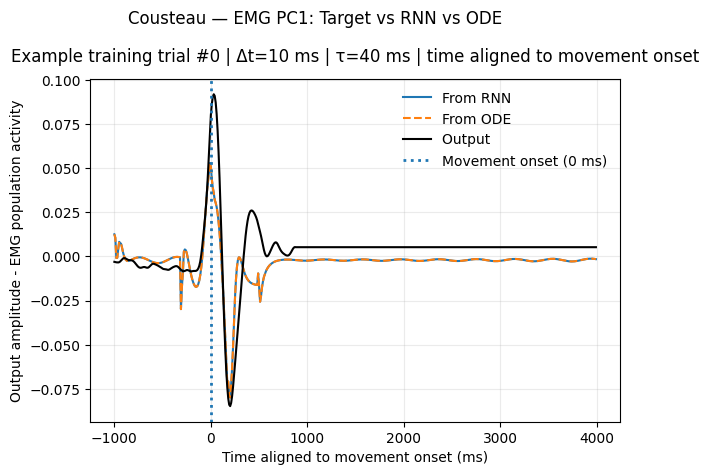

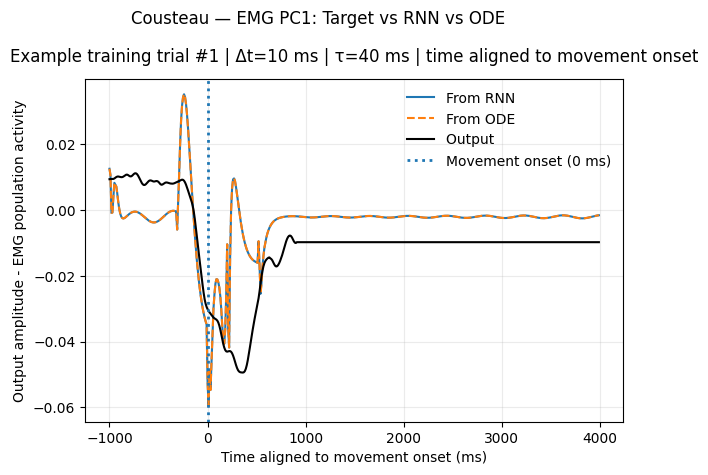

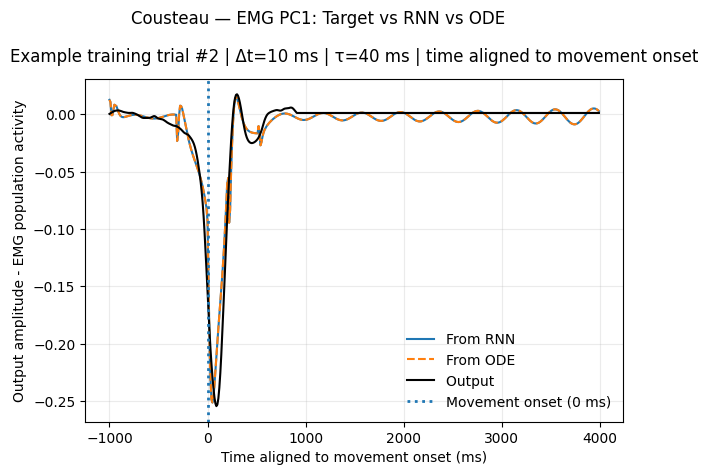

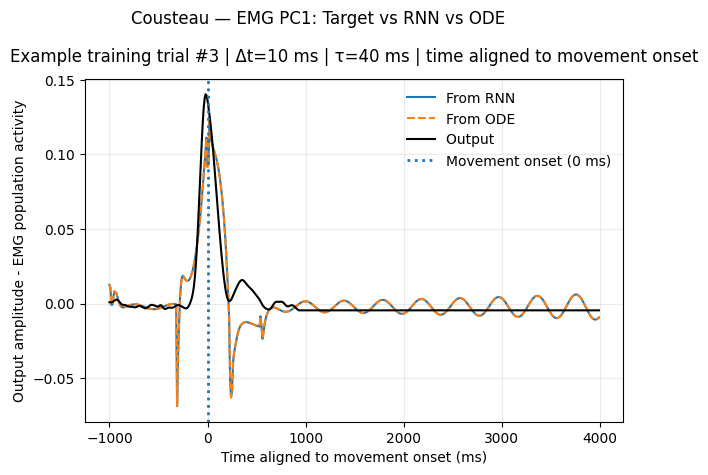

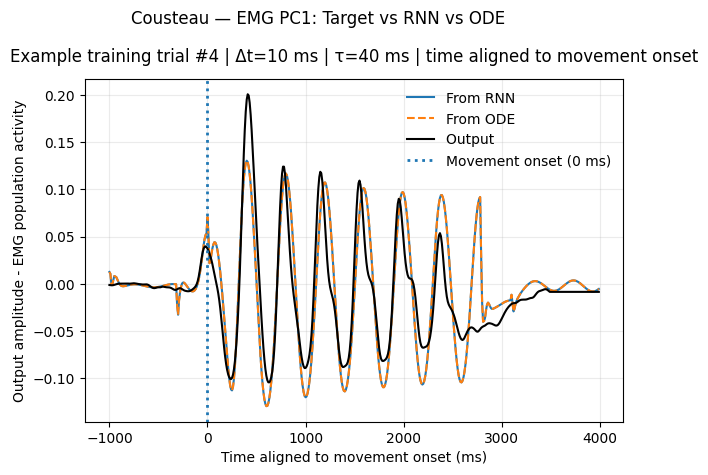

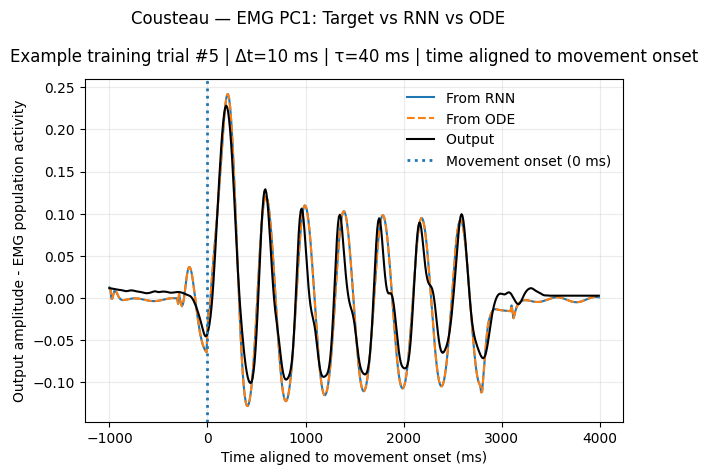

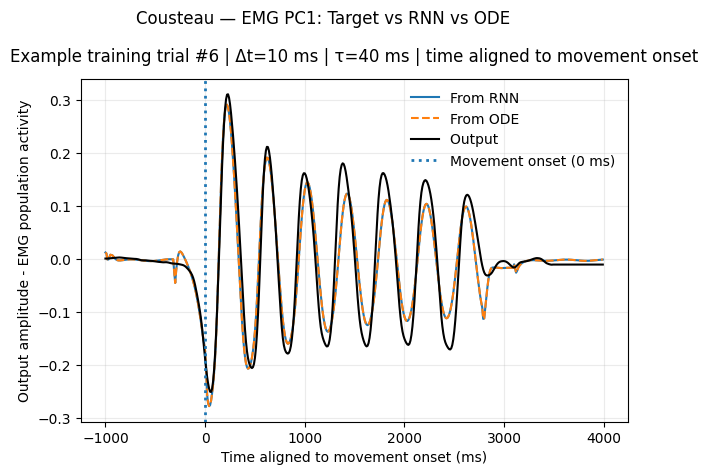

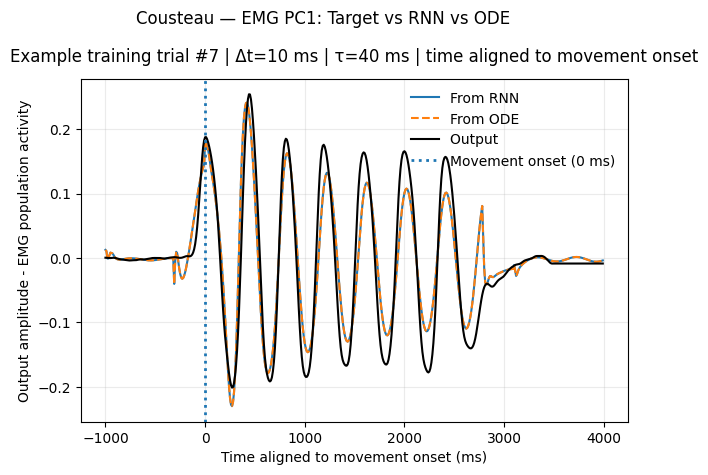

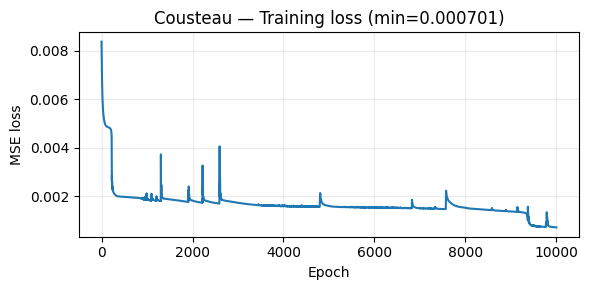

[Cousteau] Plot+eval time (s): 5.13
[Drake] Final training loss (Meval): 0.000701
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


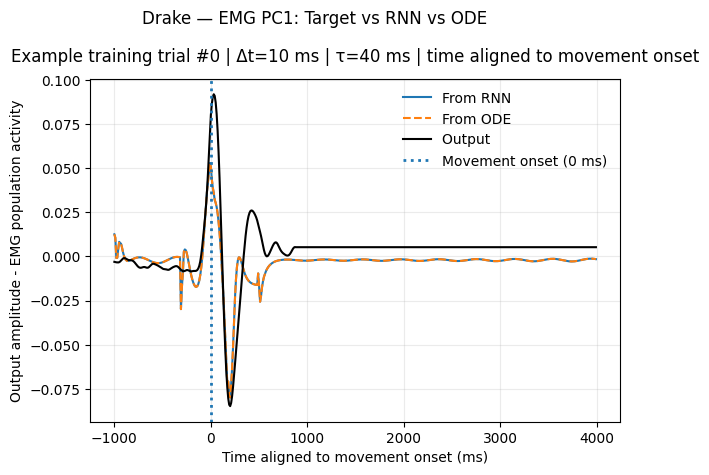

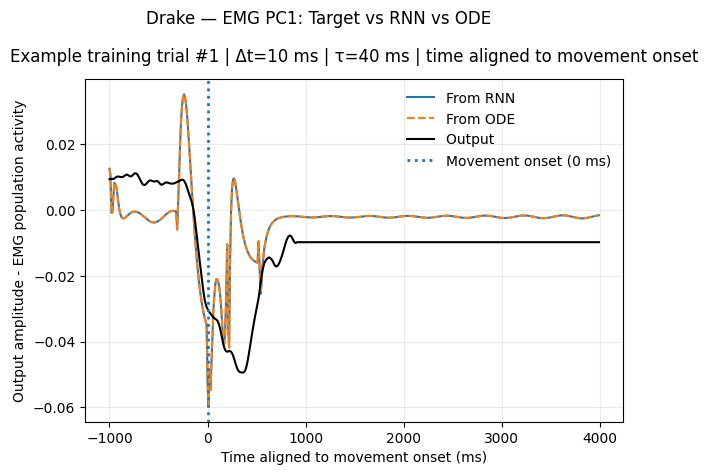

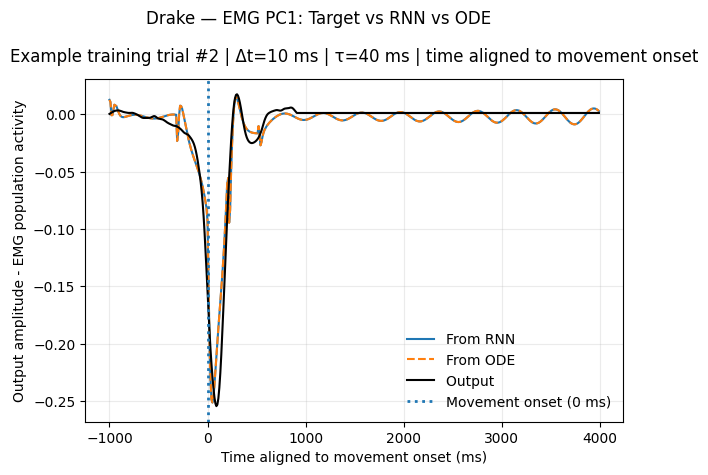

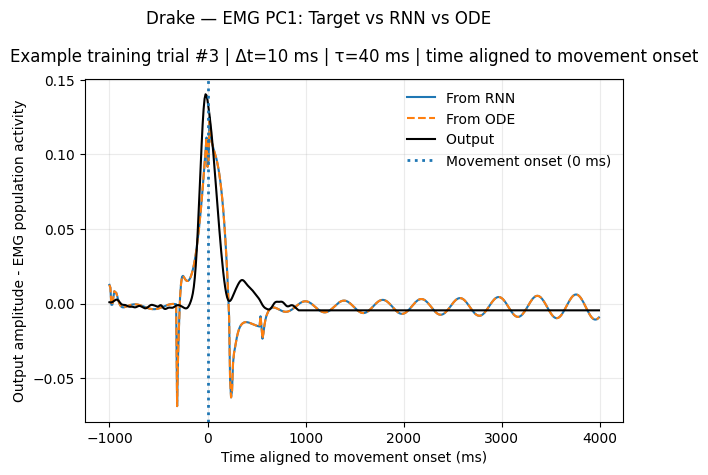

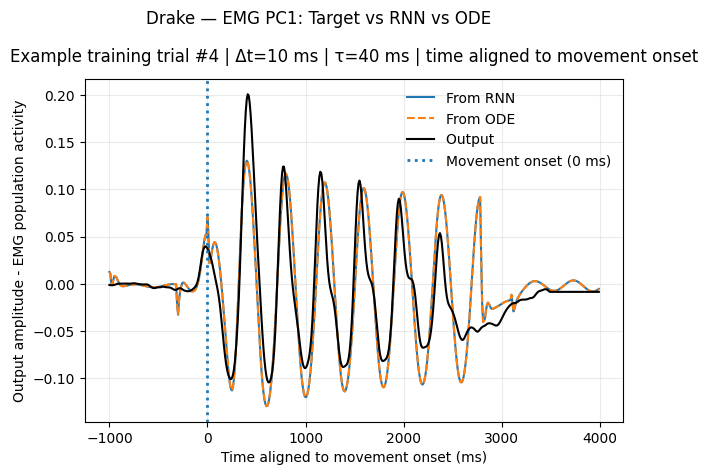

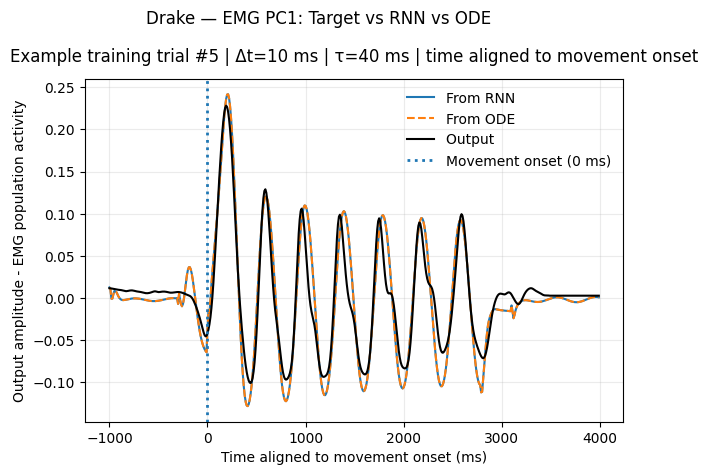

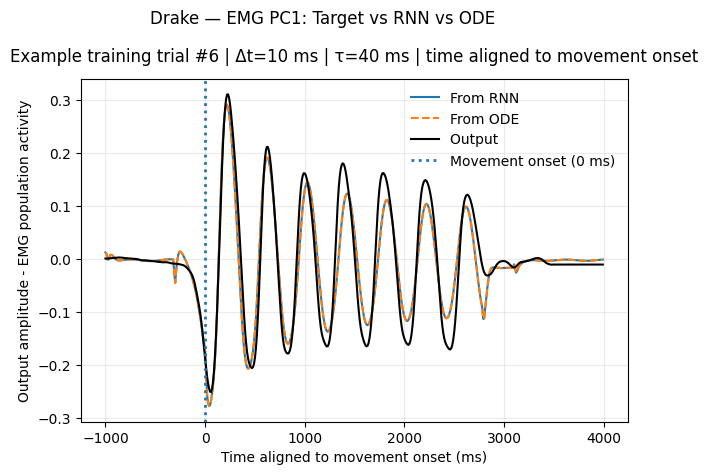

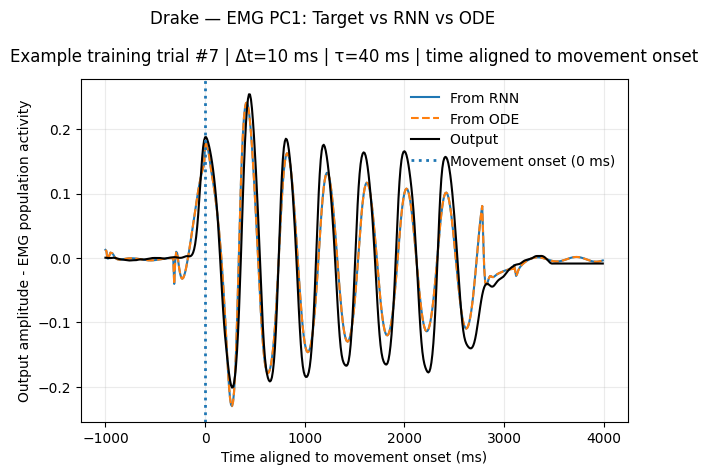

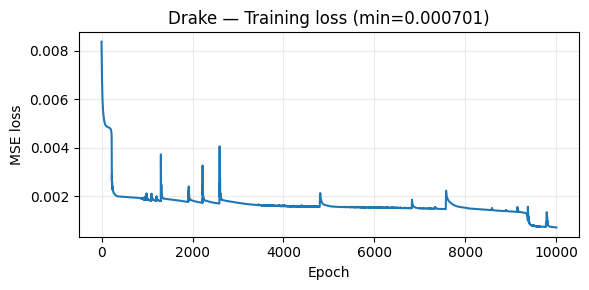

[Drake] Plot+eval time (s): 3.93


In [9]:
for Animal in ANIMALS:
    #newA=model.get_weights()
    tic = time.time()
    model.load_weights(checkpoint_filepath)
    Meval=model.evaluate(inputs_training,outputs_training,batch_size = 1, verbose = 0)
    print(f"[{Animal}] Final training loss (Meval): {Meval:.6f}")

    newA=model.get_weights()

    B     = newA[0];
    Bdir  = newA[1];
    Bipos = newA[2];
    W     = newA[3];
    O     = newA[4];
    Ob    = newA[5];

    inputPredict = model.predict(inputs_training)


    # ---- Time axis: align to movement onset  ----
    dt_ms = 10                  # Δt = 10 ms
    move_onset_idx = 100        # movement onset at index 100 -> 100*10ms = 1000 ms
    tau_ms = tau * dt_ms        # tau = 4 steps -> 40 ms

    t = (np.arange(0, Ntimes) - move_onset_idx) * dt_ms
    to = Ntimes

    # ---- Plot settings ----
    AREA_LABEL = "EMG"
    pc_idx = 0                  # 0 -> PC1
    pc_label = f"PC{pc_idx+1}"

    # Plot RNN predictions vs ODE simulation for each training trial
    for icycle in np.arange(0,len(training)):
        Output2, states2=simulateRNN(Bipos,Bdir,Btask,B,W,O,Ob,inputs_training[icycle:icycle+1,:,:],tau)

        #plt.plot(t[0:to],inputPredict[icycle,0:to,0],label='From RNN')
        plt.plot(t[0:to],inputPredict[icycle,0:to,1],label='From RNN')
        plt.plot(t[0:to],Output2[0:to,1],'--',label='From ODE ')
        plt.plot(t[0:to],outputs_training[icycle,0:to,1],'k',label='Output ')
        plt.axvline(0, linestyle=":", linewidth=2, label="Movement onset (0 ms)")

        plt.title(f"Example training trial #{icycle} | Δt={dt_ms} ms | τ={tau_ms} ms | time aligned to movement onset", fontsize=12, pad=12)
        plt.suptitle(f"{Animal} — {AREA_LABEL} PC{pc_idx+1}: Target vs RNN vs ODE")

        plt.xlabel("Time aligned to movement onset (ms)")
        plt.ylabel(f"Output amplitude - {AREA_LABEL} population activity")

        plt.legend(frameon=False)
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

    # Loss curve
    loss_val = history.history['loss']
    min_val_loss = np.min(loss_val)

    plt.figure(figsize=(6, 3))
    plt.plot(loss_val)
    plt.title(f"{Animal} — Training loss (min={min_val_loss:.6f})")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    toc = time.time()
    print(f"[{Animal}] Plot+eval time (s): {toc - tic:.2f}")



## PCA of RNN Hidden-State Dynamics

We performed PCA on the hidden-state activity of the trained RNN across all trials (training and test). Hidden states were concatenated across time to construct a population activity matrix, with each row representing a time point and each column a recurrent unit. PCA was computed on this matrix, and individual trials were projected onto the first three principal components. To compare rhythmic and discrete movements under matched conditions, we selected trials with the same initial position and movement direction but different numbers of cycles. The resulting trajectories were visualised in both state space and as temporal profiles of the first three principal components.

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[Cousteau] Same condition selected: pos=1, dir=1
         low cycles=0.5  -> trial 0
         high cycles=7.0 -> trial 16


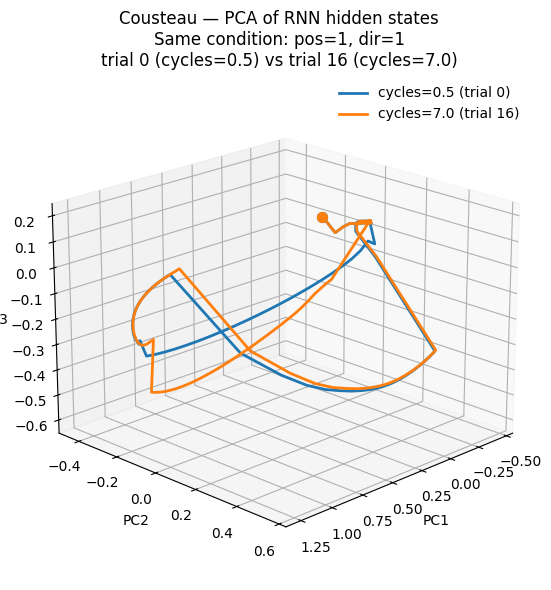

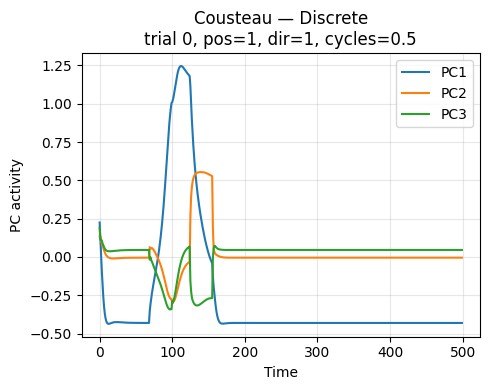

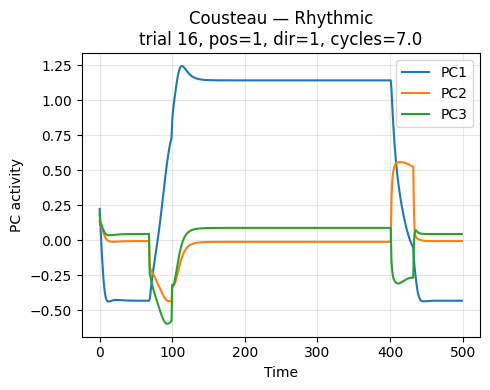

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[Drake] Same condition selected: pos=1, dir=1
         low cycles=0.5  -> trial 0
         high cycles=7.0 -> trial 16


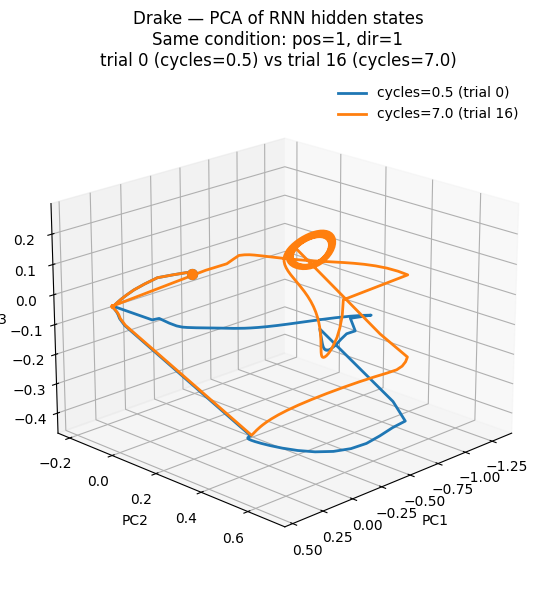

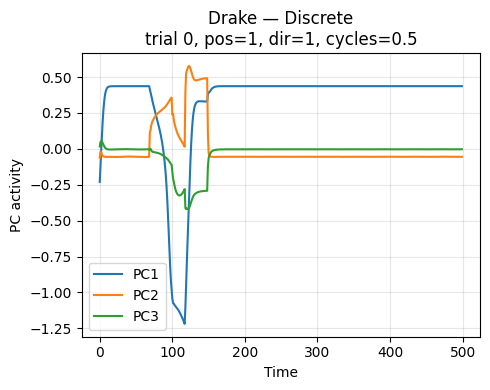

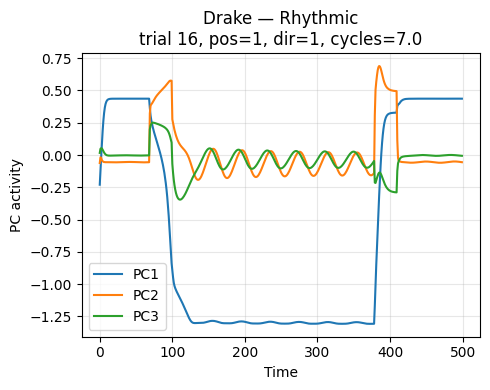

In [10]:
from sklearn.decomposition import PCA
import mpl_toolkits.mplot3d as Axes3D
ANIMALS = ["Cousteau", "Drake"]

for Animal in ANIMALS:
    # "model" must be the trained model corresponding to this animal
    # "InputDrake" must be the training inputs corresponding to this animal
    # idx_pos, idx_dir, idx_cycle must correspond to InputDrake (length = n_trials)
    Data = load_animal_mat(Animal)
    InputDrake = Data["Input"]
    idx_pos = Data["idx_pos_trial"]
    idx_dir = Data["idx_dir_trial"]
    idx_cycle = Data["idx_cycle_trial"]

    # Rebuild SAME architecture , load the correct weights for this animal
    OutputDrake = Data["Output"]
    Noutputs = OutputDrake.shape[2]
    Ntimes = InputDrake.shape[1]
    Ninputs = InputDrake.shape[2]

    cell = MinimalRNNCell(Nunits,tau,Btask)
    rnn = keras.layers.RNN(cell, return_sequences=True)

    model = keras.models.Sequential()
    model.add(keras.Input(shape=(Ntimes, Ninputs)))
    model.add(rnn)
    model.add(keras.layers.Dense(Noutputs))
    model.compile(loss="mean_squared_error", optimizer="Adam")

    #f".\Trained_Init_pos\checkpoint_EMG_Hyp_different_{Animal}.weights.h5"
    ckpt = f"./checkpoint_EMG_Hyp_different_{Animal}.weights.h5"
    model.load_weights(ckpt)

    # Build a model that outputs only the hidden states of the trained RNN
    model2 = keras.models.Sequential()
    model2.add(model.layers[0])  # trained RNN layer
    out_vals = model2.predict(InputDrake, verbose=0)  # (n_trials, Ntimes, Nunits)

    n_trials, Ntimes, Nunits = out_vals.shape

    # PCA over all trials
    states_all = out_vals.reshape(-1, Nunits)  # (20*500, Nunits)
    pca = PCA(n_components=3)
    PCs_all = pca.fit_transform(states_all)
    PCs = PCs_all.reshape(n_trials, Ntimes, 3)

    # Labels
    pos = np.asarray(idx_pos).squeeze()
    direc = np.asarray(idx_dir).squeeze()
    cycles = np.asarray(idx_cycle).squeeze()

    # Find a (pos, dir) pair that has at least 2 different cycle values
    chosen_pos = None
    chosen_dir = None

    for p in np.unique(pos):
        for d in np.unique(direc):
            trials_pd = np.where((pos == p) & (direc == d))[0]
            if trials_pd.size < 2:
                continue
            cyc_pd = np.unique(cycles[trials_pd])
            if cyc_pd.size >= 2:
                chosen_pos, chosen_dir = p, d
                break
        if chosen_pos is not None:
            break

    if chosen_pos is None:
        print(f"[{Animal}] No (pos,dir) pair found with >=2 different cycle values")
        continue

    trials_pd = np.where((pos == chosen_pos) & (direc == chosen_dir))[0]
    cyc_pd = np.unique(cycles[trials_pd])

    low_c = cyc_pd.min()
    high_c = cyc_pd.max()

    trial_low = int(trials_pd[np.where(cycles[trials_pd] == low_c)[0][0]])
    trial_high = int(trials_pd[np.where(cycles[trials_pd] == high_c)[0][0]])

    print(f"[{Animal}] Same condition selected: pos={chosen_pos}, dir={chosen_dir}")
    print(f"         low cycles={low_c}  -> trial {trial_low}")
    print(f"         high cycles={high_c} -> trial {trial_high}")

    # 3D plot PCA
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(PCs[trial_low, :, 0],  PCs[trial_low, :, 1],  PCs[trial_low, :, 2],
            linewidth=2, label=f"cycles={low_c} (trial {trial_low})")
    ax.plot(PCs[trial_high, :, 0], PCs[trial_high, :, 1], PCs[trial_high, :, 2],
            linewidth=2, label=f"cycles={high_c} (trial {trial_high})")

    # mark first timepoint as onset marker (adjust if you have a specific onset index)
    ax.scatter(PCs[trial_low, 0, 0],  PCs[trial_low, 0, 1],  PCs[trial_low, 0, 2],  s=50)
    ax.scatter(PCs[trial_high, 0, 0], PCs[trial_high, 0, 1], PCs[trial_high, 0, 2], s=50)

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(
    f"{Animal} — PCA of RNN hidden states\n"
    f"Same condition: pos={chosen_pos}, dir={chosen_dir}\n"
    f"trial {trial_low} (cycles={low_c}) vs trial {trial_high} (cycles={high_c})")

    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
    ax.view_init(elev=20, azim=45)

    plt.tight_layout()
    plt.show()

    # PC1 PC2 PC3 vs time

    # discrete
    plt.figure(figsize=(5, 4))
    plt.plot(PCs[trial_low, :, 0], label="PC1")
    plt.plot(PCs[trial_low, :, 1], label="PC2")
    plt.plot(PCs[trial_low, :, 2], label="PC3")
    plt.title(
        f"{Animal} — Discrete\n"
        f"trial {trial_low}, pos={chosen_pos}, dir={chosen_dir}, cycles={low_c}"
    )
    plt.xlabel("Time")
    plt.ylabel("PC activity")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # rhythmic
    plt.figure(figsize=(5, 4))
    plt.plot(PCs[trial_high, :, 0], label="PC1")
    plt.plot(PCs[trial_high, :, 1], label="PC2")
    plt.plot(PCs[trial_high, :, 2], label="PC3")
    plt.title(
        f"{Animal} — Rhythmic\n"
        f"trial {trial_high}, pos={chosen_pos}, dir={chosen_dir}, cycles={high_c}"
    )
    plt.xlabel("Time")
    plt.ylabel("PC activity")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
